<a href="https://colab.research.google.com/github/gauri-s-gb/stats-course/blob/main/CSSL_06_polynomial_regression_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial regression
Let's try loading a dataset a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file.

In [37]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gaurishere","key":"38b84647b439486df7a1a9186a5f7919"}'}

In [38]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [39]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [40]:
!kaggle datasets download -d mirajdeepbhandari/polynomial-regression

Dataset URL: https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression
License(s): CC0-1.0
  0% 0.00/1.18k [00:00<?, ?B/s]
100% 1.18k/1.18k [00:00<00:00, 3.89MB/s]


In [41]:
!unzip polynomial-regression.zip

Archive:  polynomial-regression.zip
  inflating: Ice_cream selling data.csv  


In [42]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import scale, PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay

In [43]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'kaggle.json',
 'config.seb',
 'kaggle(1) (1).json',
 'polynomial-regression.zip',
 'kaggle(1).json',
 'Ice_cream selling data.csv',
 'sample_data']

The Ice_cream selling data.csv is available!

In [44]:
data = pd.read_csv("Ice_cream selling data.csv") # Read the csv file into a pandas dataframe
type(data)

pandas.core.frame.DataFrame

In [46]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [47]:
data.shape

(49, 2)

In [48]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [49]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [50]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [51]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

1 143.09841013876851 144.60468995048183
[143.09841013876851] [144.60468995048183]
-0.03912798782600069
2 9.861627186505526 12.351860655176438
[143.09841013876851, 9.861627186505526] [144.60468995048183, 12.351860655176438]
0.9112396415848207
3 9.32762657521549 10.588172153545953
[143.09841013876851, 9.861627186505526, 9.32762657521549] [144.60468995048183, 12.351860655176438, 10.588172153545953]
0.9239134911292493
4 8.413880588046377 10.547045605847865
[143.09841013876851, 9.861627186505526, 9.32762657521549, 8.413880588046377] [144.60468995048183, 12.351860655176438, 10.588172153545953, 10.547045605847865]
0.9242090261272523
5 8.322506351123161 11.422889154269622
[143.09841013876851, 9.861627186505526, 9.32762657521549, 8.413880588046377, 8.322506351123161] [144.60468995048183, 12.351860655176438, 10.588172153545953, 10.547045605847865, 11.422889154269622]
0.9179152223479036
6 7.97086018158074 31.322635297207633
[143.09841013876851, 9.861627186505526, 9.32762657521549, 8.4138805880463

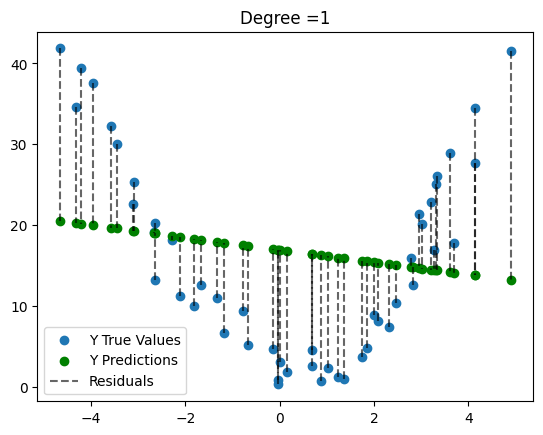

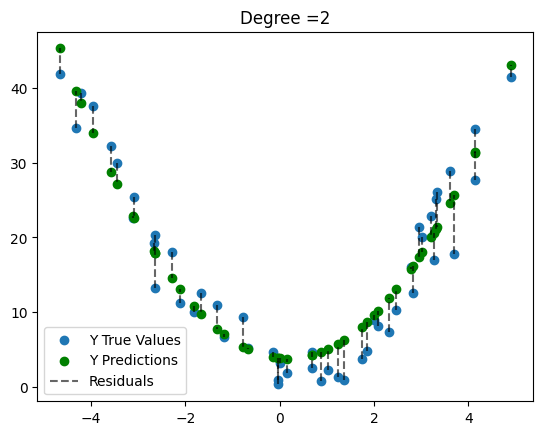

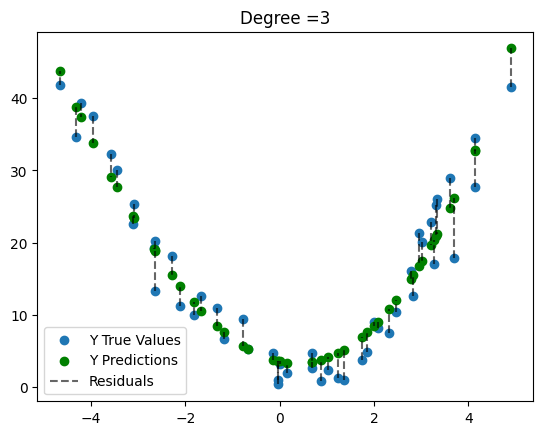

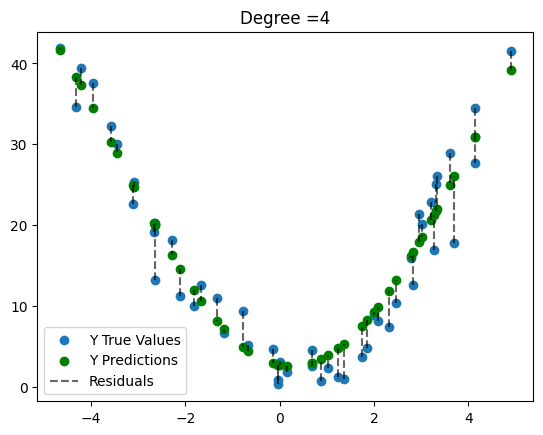

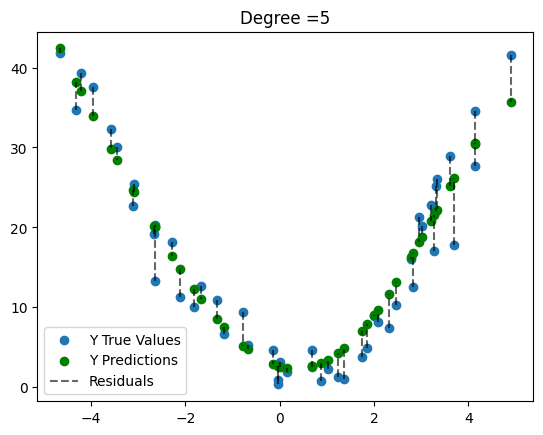

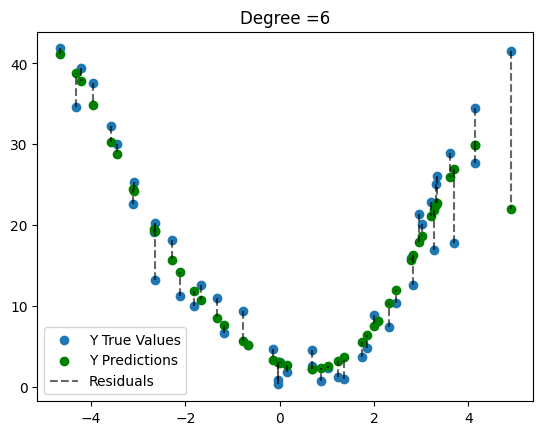

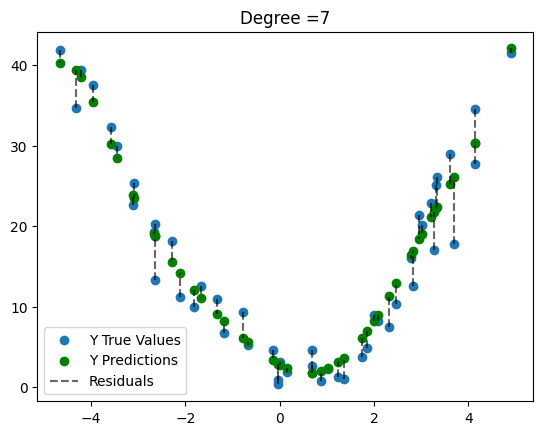

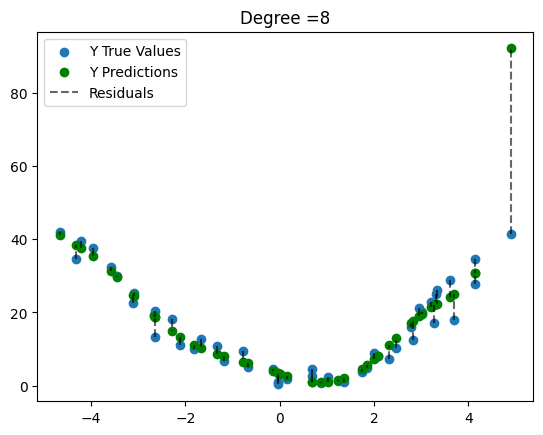

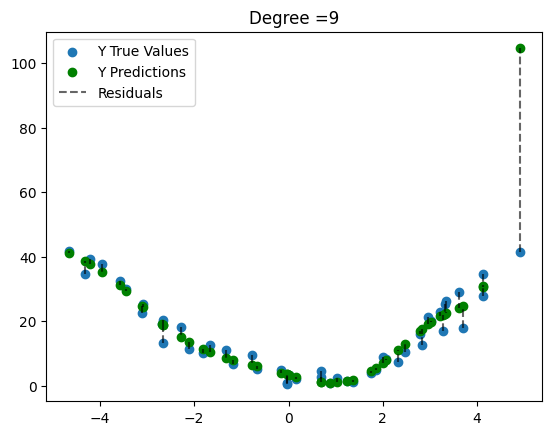

In [61]:
degrees = range(1,10)
train_errors = []
test_errors = []
for degree in degrees:
  if degree>1:
    poly_features = PolynomialFeatures(degree=degree)
    X_transformed = poly_features.fit_transform(X)

  else:
    X_transformed = X.copy()

  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.3, random_state=0)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  y_pred_all = model.predict(X_transformed)
  train_error = mean_squared_error(y_train, y_pred_train)
  train_errors.append(train_error)
  test_error = mean_squared_error(y_test, y_pred_test)
  test_errors.append(test_error)
  print(degree, train_error, test_error)
  plt.figure()
  plt.scatter(X, y, label = 'Y True Values')
  plt.scatter(X, y_pred_all, color="g", label = "Y Predictions")
  plt.vlines(X, y, y_pred_all, color = "k", linestyle = "--", alpha = 0.6, label = "Residuals")
  plt.title(f"Degree ={degree}")
  print(train_errors, test_errors)
  print(r2_score(y_test, y_pred_test))
  plt.legend()




<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

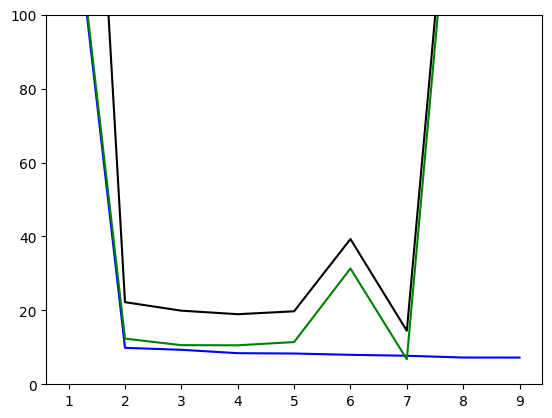

In [62]:
plt.figure()
plt.plot(degrees, train_errors, color="b", label="train_error")
plt.plot(degrees, test_errors, color="g", label="test_error")
plt.plot(degrees, np.array(train_errors)+np.array(test_errors), c="k", label="total error")
plt.ylim(0,100)
plt.legend

In [63]:
#issue comes in with the weird blip that's there on the graph! small differences that the model is calculating to fit the data better is not getting recorded. the blue line should not happen ideally (training line)

type(X.iloc[0,0]) #64 = longest string to represent this is 64 bits. (bits = each 0 and 1 in the binary code- the string is 64 characters long)
# x belongs to the range of [-5, 5].
#the largest decimal value that the bit can store is 10^-16.
#1 bit = sign
#11 bits = exponent
#52 bits = mantissa so if you have the number 0.514 it's represented in floating point numbers and exponents = 5.14 * 10^-2
#5.14 has the most important bits: why?
#if you have x = 5^50 - need to convert it into scientific notation = using log, need to convert it into the form of 10^x = 10^35.
#computer can only do some arithmetic of the precision 10^-16. so for x = 5^50, which is 10^35, we get 10^35 * 10^-16 = 10^19. any number as large as this will not be recorded
#to fix this, you can use a larger bit model (use smth larger than 64 bits) OR you divide the range by 5: x belongs to [-1, 1], and now x^2 belongs to [0, 1), then x^3 belongs to [-1, 1], and so on till x^50 which belongs to (0, 1].
#so now the values within your range are smaller, and the precision/resolution becomes smaller - accuracy better! if you take 0.1 it becomes 1 x 10^-1, and when using 64 bit (10^-16), the magnitude becomes 10^-17 -- so model is able to keep all information (as it is much smaller than 10^-19 compared to earlier)

numpy.float64

In [66]:
a = float(5*(10**50)) #if you do something greater than the power of 16, we lose information.
b = a + 1 #addition is so small it doesn't record it. e+50 = 10^50
print(a, b)

5e+50 5e+50


In [76]:
#in the scatter plot, as the degrees increase, we see a change in the model shape - we assume that it's following the polynomial shape - but is that really true? - didn't plot continuous line bc then the model would extrapolate data for the gaps - but this isn't accurate
X_unscaled = data.iloc[:, :-1]
X = X_unscaled.copy()
print(X_unscaled)
X["Temperature (°C)"] = X/5
print(X)
y = data.iloc[:, -1]
x_values = pd.DataFrame(data=np.arange(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 0.01), columns =["Temperature (°C)"]) #to understand what the model is doing in places we don't have data

    Temperature (°C)
0          -4.662263
1          -4.316559
2          -4.213985
3          -3.949661
4          -3.578554
5          -3.455712
6          -3.108440
7          -3.081303
8          -2.672461
9          -2.652287
10         -2.651498
11         -2.288264
12         -2.111870
13         -1.818938
14         -1.660348
15         -1.326379
16         -1.173123
17         -0.773330
18         -0.673753
19         -0.149635
20         -0.036156
21         -0.033895
22          0.008608
23          0.149245
24          0.688781
25          0.693599
26          0.874905
27          1.024181
28          1.240712
29          1.359813
30          1.740000
31          1.850552
32          1.999310
33          2.075101
34          2.318591
35          2.471946
36          2.784836
37          2.831760
38          2.959932
39          3.020874
40          3.211366
41          3.270044
42          3.316073
43          3.335932
44          3.610778
45          3.704057
46          4

1 143.09841013876851 144.60468995048183
[143.09841013876851] [144.60468995048183]
-0.03912798782600069
2 9.86162718650552 12.35186065517645


ValueError: x and y must be the same size

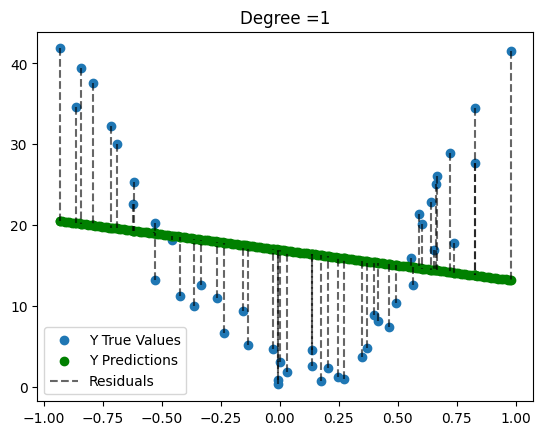

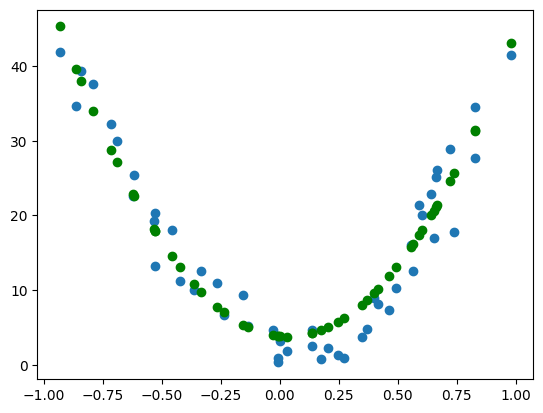

In [77]:
#smth is getting fucked up check her code. #the gaps refer to the temperatures that were never recorded - or every x value doesn't have a corresponding y value
degrees = range(1,10)
train_errors = []
test_errors = []
for degree in degrees:
  if degree>1:
    poly_features = PolynomialFeatures(degree=degree)
    X_transformed = poly_features.fit_transform(X)
    x_values_transformed = poly_features.fit_transform(x_values)

  else:
    X_transformed = X.copy()
    x_values_transformed = x_values.copy()

  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.3, random_state=0)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  y_pred_all = model.predict(X_transformed)

  y_values_predicted = model.predict(x_values_transformed)

  train_error = mean_squared_error(y_train, y_pred_train)
  train_errors.append(train_error)
  test_error = mean_squared_error(y_test, y_pred_test)
  test_errors.append(test_error)
  print(degree, train_error, test_error)
  plt.figure()
  plt.scatter(X, y, label = 'Y True Values')
  plt.scatter(X, y_pred_all, color="g", label = "Y Predictions")
  plt.scatter(x_values_transformed, y_values_predicted, c="g")
  plt.vlines(X, y, y_pred_all, color = "k", linestyle = "--", alpha = 0.6, label = "Residuals")
  plt.title(f"Degree ={degree}")
  print(train_errors, test_errors)
  print(r2_score(y_test, y_pred_test))
  plt.legend()
#she put y limit as 0,40 to see the actual way overfitting happens! that's why there are still some gaps - but don't focus on that
#loss function wants to minimize the residuals - so how does this make the training error small and the test error huge? - nneed to look @ that
#more squiggly for points which are in the test dataset that were not there in the training dataset????